<a href="https://colab.research.google.com/github/abhayjha800/ML_Projects/blob/main/regression_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [225]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

In [226]:
df = pd.read_csv('Admission_Predict.csv')

In [227]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [228]:
df.shape

(400, 9)

In [229]:
df.drop(columns=['Serial No.'], inplace=True)

In [230]:
X_test, X_train, y_test, y_train = train_test_split(df.drop(columns=['Chance of Admit ']), df['Chance of Admit '], test_size=0.2, random_state=42)

In [231]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [232]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

In [233]:
class CustomDataset(Dataset):
  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.float32)

  def __len__(self):
    return len(self.labels)

  def __getitem__(self, idx):
    return self.features[idx], self.labels[idx]

In [234]:
train_dataset = CustomDataset(X_train, y_train.values)
test_dataset = CustomDataset(X_test, y_test.values)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [235]:
class LinearRegressionModel(nn.Module):
  def __init__(self, input_dim):
    super(LinearRegressionModel, self).__init__()
    self.network = nn.Sequential(
        nn.Linear(input_dim, 16),
        nn.ReLU(),
        nn.Linear(16,16),
        nn.ReLU(),
        nn.Linear(16, 1)
    )

  def forward(self, x):
    return self.network(x)

In [236]:
model = LinearRegressionModel(X_train.shape[1])

In [237]:
# !pip install torchinfo
from torchinfo import summary

In [238]:
summary(model)

Layer (type:depth-idx)                   Param #
LinearRegressionModel                    --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       128
│    └─ReLU: 2-2                         --
│    └─Linear: 2-3                       272
│    └─ReLU: 2-4                         --
│    └─Linear: 2-5                       17
Total params: 417
Trainable params: 417
Non-trainable params: 0

In [239]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [240]:
epochs = 20

training_loss = []
validation_loss = []

for epoch in range(epochs):
  model.train()
  running_loss = 0

  for features, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(features)
    loss = criterion(outputs, labels.unsqueeze(1))
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
  training_loss.append(running_loss / len(train_loader))

  model.eval()
  with torch.no_grad():
    val_loss = 0
    for features, labels in test_loader:
      outputs = model(features)
      loss = criterion(outputs, labels.unsqueeze(1))
      val_loss += loss.item()
  validation_loss.append(val_loss / len(test_loader))
  print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss / len(train_loader):.4f}')


Epoch [1/20], Loss: 0.3618
Epoch [2/20], Loss: 0.1282
Epoch [3/20], Loss: 0.0244
Epoch [4/20], Loss: 0.0360
Epoch [5/20], Loss: 0.0095
Epoch [6/20], Loss: 0.0167
Epoch [7/20], Loss: 0.0092
Epoch [8/20], Loss: 0.0079
Epoch [9/20], Loss: 0.0080
Epoch [10/20], Loss: 0.0062
Epoch [11/20], Loss: 0.0063
Epoch [12/20], Loss: 0.0058
Epoch [13/20], Loss: 0.0057
Epoch [14/20], Loss: 0.0053
Epoch [15/20], Loss: 0.0054
Epoch [16/20], Loss: 0.0053
Epoch [17/20], Loss: 0.0052
Epoch [18/20], Loss: 0.0052
Epoch [19/20], Loss: 0.0051
Epoch [20/20], Loss: 0.0052


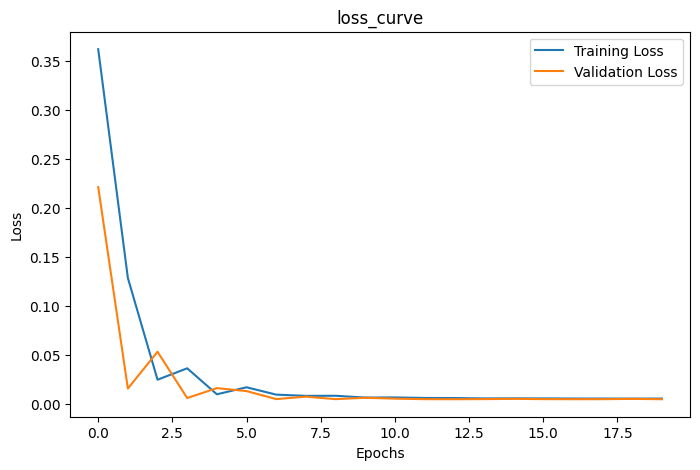

In [246]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(training_loss, label='Training Loss')
ax.plot(validation_loss, label='Validation Loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title('loss_curve')
ax.legend()

In [242]:
model.eval()
all_pred = []
all_labels = []
for features, labels in test_loader:
  outputs = model(features)
  all_pred.extend(outputs.squeeze().tolist())
  all_labels.extend(labels.tolist())


In [243]:
all_pred

[0.7712435126304626,
 0.7240595817565918,
 0.9987818598747253,
 0.736335039138794,
 0.5698596835136414,
 0.726636528968811,
 0.7995550632476807,
 0.6922452449798584,
 0.9189695715904236,
 0.683509886264801,
 0.5605438351631165,
 0.8418571352958679,
 0.4792882800102234,
 0.6903805136680603,
 0.5843484997749329,
 0.5911035537719727,
 0.7479174733161926,
 0.778020441532135,
 0.5007792711257935,
 0.7685014605522156,
 0.6315819621086121,
 0.6457223892211914,
 0.7054573893547058,
 0.7693753242492676,
 0.7193975448608398,
 0.5704623460769653,
 0.6220420598983765,
 0.6502555012702942,
 0.6157006025314331,
 0.6000967025756836,
 0.6811800003051758,
 0.5765015482902527,
 0.516033411026001,
 0.5478019714355469,
 0.7823283672332764,
 0.5880844593048096,
 0.4238011837005615,
 0.8920665979385376,
 0.7798038721084595,
 0.805523157119751,
 0.5948361754417419,
 0.679282546043396,
 0.699162483215332,
 0.4515519142150879,
 0.9639833569526672,
 0.8074617981910706,
 0.7913974523544312,
 0.6727662086486816,


In [244]:
from sklearn.metrics import r2_score

In [245]:
r2_score(all_labels, all_pred)

0.7625256121054667